# 02 — Gradient Boosting Model

This notebook trains and evaluates a Gradient Boosting classifier for Parkinson’s Disease detection using cleaned MDVP voice features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [2]:
BASE_DIR = Path("..")

DATA_PATH = BASE_DIR / "data" / "processed" / "pd_cleaned.csv"

RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Cleaned data path:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

Cleaned data path: ..\data\processed\pd_cleaned.csv
Exists: True


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (224, 17)


,jitt,jita,RAP,PPQ,sPPQ,vfo,shim,shdb,APQ,sAPQ,vAm,ATRI,FTRI,VTI,SPI,NHR,status
0,0.6,31,0.3,0.3,0.6,1.3,3.6,0.30,2.1,4.2,36.2,2.1,0.4,13.71,4.14,27.39,1
1,1.3,60,0.8,0.6,0.9,1.8,10.6,1.06,5.3,8.0,26.0,6.2,0.6,12.05,5.24,22.47,1
2,1.4,75,0.9,0.7,1.3,2.7,12.7,1.28,6.7,15.0,39.8,7.6,1.0,11.82,7.56,16.12,1
3,1.0,53,0.6,0.6,0.9,1.3,5.7,0.50,3.5,6.5,24.5,3.2,0.7,17.71,5.48,16.74,1
4,1.8,90,1.2,0.9,1.2,1.5,9.7,1.17,4.8,9.3,72.5,4.6,0.9,13.93,3.94,24.29,1


In [4]:
TARGET_COL = "status"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (224, 16)
Target shape: (224,)


In [5]:
y.value_counts()
(y.value_counts(normalize=True) * 100).round(2)

status
1    82.14
0    17.86
Name: proportion, dtype: float64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("y_test distribution:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (179, 16)
X_test: (45, 16)
y_train distribution:
status
1    0.821
0    0.179
Name: proportion, dtype: float64
y_test distribution:
status
1    0.822
0    0.178
Name: proportion, dtype: float64


In [7]:
gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', GradientBoostingClassifier(random_state=42))])

In [8]:
gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', GradientBoostingClassifier(random_state=42))])

In [9]:
y_pred = gb_pipeline.predict(X_test)
y_prob = gb_pipeline.predict_proba(X_test)[:, 1]

In [10]:
gb_metrics = {
    "model": "Gradient Boosting",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
    "mcc": matthews_corrcoef(y_test, y_pred)
}

gb_metrics

{'model': 'Gradient Boosting',
 'accuracy': 0.9555555555555556,
 'precision': 0.9487179487179487,
 'recall': 1.0,
 'f1_score': 0.9736842105263158,
 'roc_auc': 0.9797297297297297,
 'mcc': 0.8435273922869735}

In [11]:
gb_metrics_df = pd.DataFrame([gb_metrics])
gb_metrics_df.to_csv(METRICS_DIR / "gradient_boosting_metrics.csv", index=False)

gb_metrics_df

,model,accuracy,precision,recall,f1_score,roc_auc,mcc
0,Gradient Boosting,0.955556,0.948718,1.0,0.973684,0.97973,0.843527


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       0.95      1.00      0.97        37

    accuracy                           0.96        45
   macro avg       0.97      0.88      0.92        45
weighted avg       0.96      0.96      0.95        45



In [13]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 6,  2],
       [ 0, 37]], dtype=int64)

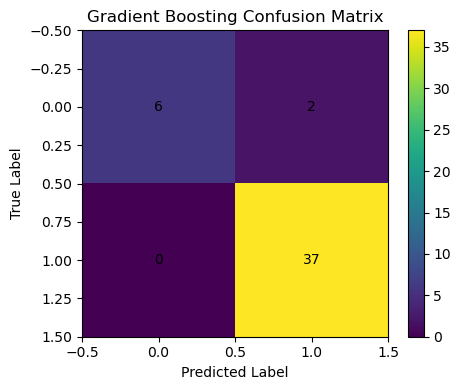

In [14]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "gradient_boosting_confusion_matrix.png", dpi=300)
plt.show()

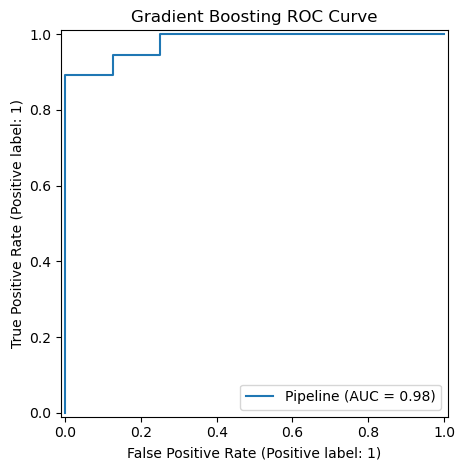

In [15]:
RocCurveDisplay.from_estimator(gb_pipeline, X_test, y_test)

plt.title("Gradient Boosting ROC Curve")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gradient_boosting_roc_curve.png", dpi=300)
plt.show()

In [16]:
gb_model = gb_pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": gb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
10,vAm,0.218151
15,NHR,0.121320
13,VTI,0.109278
2,RAP,0.080044
9,sAPQ,0.072185
14,SPI,0.063849
5,vfo,0.062199
3,PPQ,0.059881
12,FTRI,0.058832
1,jita,0.046489


In [17]:
feature_importance.to_csv(
    METRICS_DIR / "gradient_boosting_feature_importance.csv",
    index=False
)

print("Saved feature importance.")

Saved feature importance.


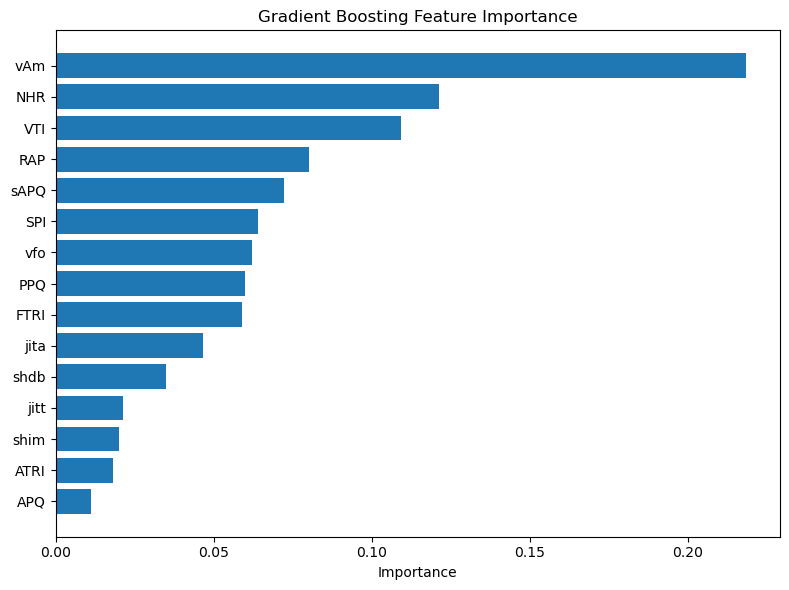

In [18]:
top_features = feature_importance.head(15).sort_values(by="importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gradient_boosting_feature_importance.png", dpi=300)
plt.show()

## Gradient Boosting Summary

The Gradient Boosting classifier was trained using cleaned MDVP voice features.

Evaluation included:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Matthews Correlation Coefficient
- Confusion matrix
- ROC curve
- Feature importance

Because the dataset is imbalanced, F1-score, ROC-AUC, recall, and MCC are more informative than accuracy alone.